In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression,Ridge, Lasso, ElasticNet,LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report, auc, roc_auc_score

In [4]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [5]:
df.sample(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
85554,Female,36.0,0,0,No Info,25.74,4.8,85,0
27915,Female,54.0,0,0,former,28.35,6.0,80,0
64457,Female,26.0,0,0,never,27.32,4.8,155,0
2035,Female,17.0,0,0,No Info,24.14,6.0,85,0
89897,Male,62.0,0,0,former,31.73,4.0,126,0


In [6]:
df.shape

(100000, 9)

In [5]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [6]:
df.isnull().mean()

gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
smoking_history        0.0
bmi                    0.0
HbA1c_level            0.0
blood_glucose_level    0.0
diabetes               0.0
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(3854)

In [8]:
df = df.drop_duplicates()

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 9.4+ MB


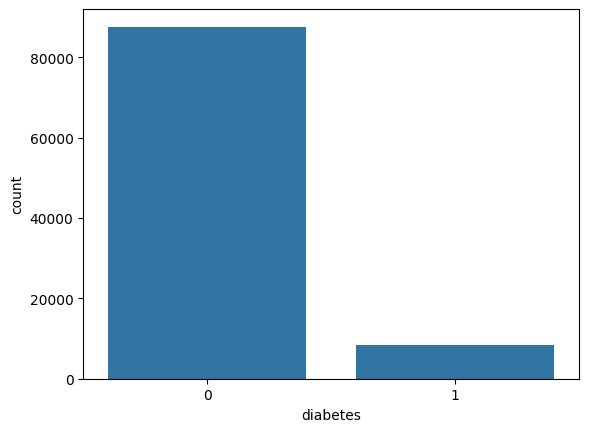

In [95]:
sns.countplot(data=df, x='diabetes')
plt.show()

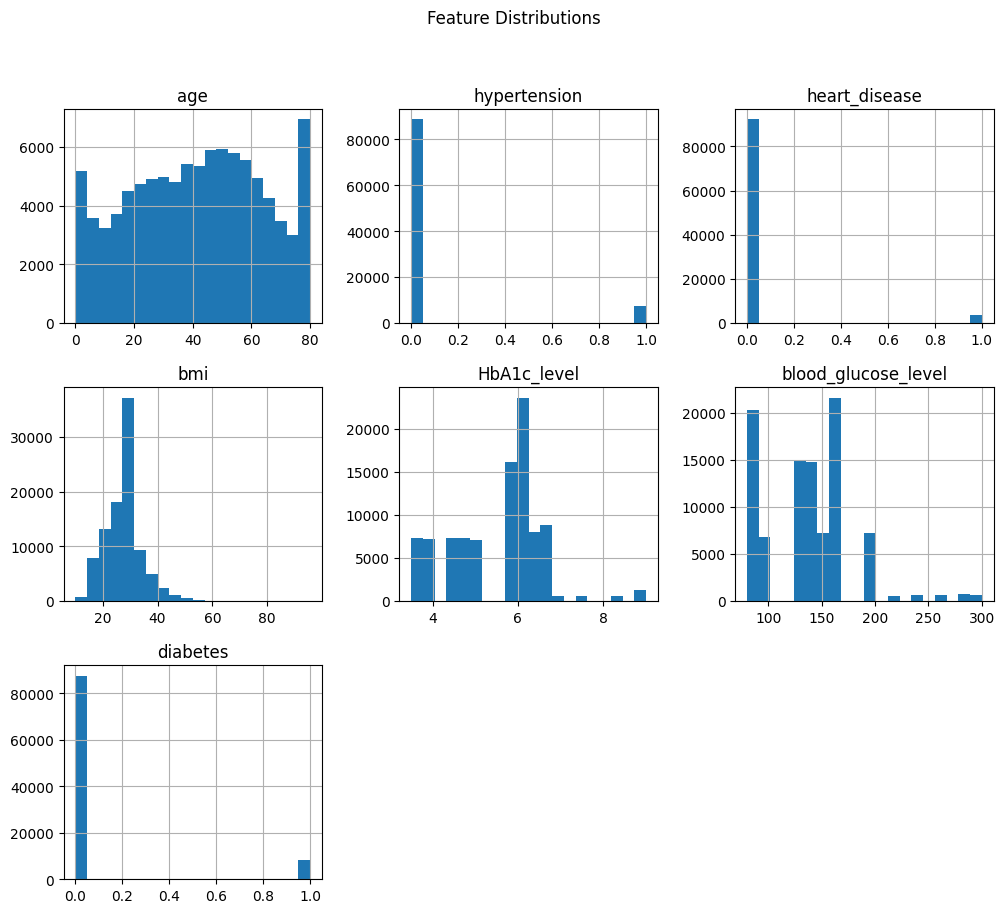

In [9]:
df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

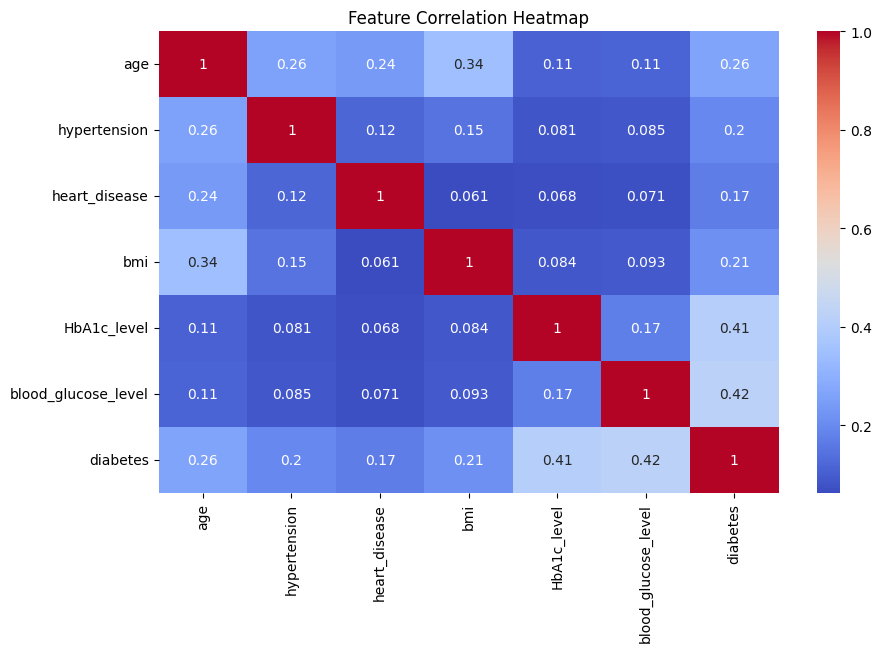

In [11]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
df['diabetes'].value_counts(normalize = True)

diabetes
0    0.91178
1    0.08822
Name: proportion, dtype: float64

In [10]:
X = df.drop("diabetes",axis = 1)
y = df["diabetes"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1,random_state = 42, stratify = y)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(86531, 8)
(9615, 8)
(86531,)
(9615,)


In [13]:
num = X.select_dtypes(exclude = ['object']).columns
cat = X.select_dtypes(include = ['object']).columns

In [14]:
process = ColumnTransformer(   
    transformers = [("num",StandardScaler(),num),
                     ("cat",OneHotEncoder(handle_unknown = "ignore"),cat)
                   ]
)

## Random Forest Classifier

In [15]:
model1 = RandomForestClassifier(n_estimators = 200,max_depth = 8,random_state = 42)
clf1 = Pipeline(steps=[("preprocessor",process),("model1",model1)])
clf1.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model1', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
y_pred1 = clf1.predict(X_test)

In [17]:
accuracy_score(y_test,y_pred1)

0.9711908476339054

In [18]:
classification_report(y_test,y_pred1)

'              precision    recall  f1-score   support\n\n           0       0.97      1.00      0.98      8767\n           1       1.00      0.67      0.80       848\n\n    accuracy                           0.97      9615\n   macro avg       0.98      0.84      0.89      9615\nweighted avg       0.97      0.97      0.97      9615\n'

In [19]:
confusion_matrix(y_test,y_pred1)

array([[8767,    0],
       [ 277,  571]])

In [20]:
y_prob_rf = clf1.predict_proba(X_test)[:,1]
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))

RF AUC: 0.9616398248362749


In [31]:
model1.feature_importances_

array([5.05148990e-02, 1.92023093e-02, 1.29085159e-02, 2.70983142e-02,
       4.97969226e-01, 3.84072648e-01, 6.90918968e-04, 7.85629013e-04,
       2.50029699e-07, 3.76403009e-03, 1.90290184e-04, 1.48496896e-04,
       2.09539477e-03, 3.70808031e-04, 1.88269618e-04])

## Logistic Regression

In [23]:
model2 = LogisticRegression(max_iter = 1000)
clf2 = Pipeline(steps=[("preprocessor",process),("model2",model2)])
clf2.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred2 = clf2.predict(X_test)

In [25]:
accuracy_score(y_test,y_pred2)

0.9597503900156006

In [26]:
classification_report(y_test,y_pred2)

'              precision    recall  f1-score   support\n\n           0       0.96      0.99      0.98      8767\n           1       0.88      0.63      0.73       848\n\n    accuracy                           0.96      9615\n   macro avg       0.92      0.81      0.86      9615\nweighted avg       0.96      0.96      0.96      9615\n'

In [27]:
confusion_matrix(y_test,y_pred2)

array([[8696,   71],
       [ 316,  532]])

In [28]:
y_prob_lr = clf2.predict_proba(X_test)[:,1]
print("LR AUC:", roc_auc_score(y_test, y_prob_lr))

LR AUC: 0.9568939914043013


In [ ]:
# Choosing RandomForetClissifier as it has higher accuracy.

In [ ]:
# Predicting

In [26]:
def predict_diabetes(gender, age, hypertension, heart_disease,
                     smoking_history, bmi, HbA1c_level, blood_glucose_level):

    input_data = pd.DataFrame([{
        "gender": gender,
        "age": age,
        "hypertension": hypertension,
        "heart_disease": heart_disease,
        "smoking_history": smoking_history,
        "bmi": bmi,
        "HbA1c_level": HbA1c_level,
        "blood_glucose_level": blood_glucose_level
    }])

    prediction = clf1.predict(input_data)[0]

    return "Diabetes" if prediction == 1 else "No diabetes"


print(predict_diabetes("Female", 80, 0, 1, "never", 25.19, 6.6, 140))

No diabetes


In [32]:
import joblib
joblib.dump(clf1,'diabetes_pred.pkl')

['diabetes_pred.pkl']